In [1]:
from Observation import *
from reduction_tools import *

%matplotlib qt
from interactive_reduction_tools import *

import os
import numpy as np
from astropy.io import fits

from matplotlib import pyplot as plt
import matplotlib as mpl
from cycler import cycler
from matplotlib.colors import LogNorm

colors = iter([plt.cm.Set1(i) for i in range(20)])
default_cycler = cycler(color=colors)
plt.rc('axes', prop_cycle=default_cycler)

Here is a basic tutorial on how to use the interactive functionality of this EMIR GTC pipeline. The previous example shows how this pipeline is broken up into 5 steps for each needed spectrum. The step that can be interactive for this example is in-between the ABBA subtraction and flux conversion step, where the system needs to find the pixels that correspond to the supernova spectrum:

1. Object and File System Initialization
2. Rectification and Calibration
3. ABBA Subtraction

* __*interactive position finder*__

4. Flux Conversion
5. Saving Results

This extra step is outlined below. Before running this example, you must run the `OB0012_interactive_repsonse_curve` example, as this will store important variables for the response curve. 

In [2]:
# load the response curve information
o12 = Observation("OB0012")

if not os.path.exists('OB0012/results/response_curve/YJ_response_curve.fits'):
    o12.initialize('object', 'YJ')
    o12.rectify_and_analyze('object','YJ')
    o12.ABBA_subtract('YJ')

o12_kwargs = get_parameters(o12, 'YJ')
o12.make_response_curve('OB0012/uka0v.fits', 'YJ', **o12_kwargs)
print("Pre-loaded response curve parameters:", o12_kwargs)

# start to reduce the spectrum
o = Observation("OB0011")

if not os.path.exists('OB0011/results/ABBA/ABBA_subtracted_YJ.fits'):
    o.initialize('object', 'YJ')
    o.rectify_and_analyze('object','YJ')
    o.ABBA_subtract('YJ')

Pre-loaded response curve parameters: {'SN_position': (1184, 1236), 'sample_points': [8900.0, 9164.13620967742, 10190.754285714285, 10803.602338709677, 12215.364838709676, 12989.557177419354, 13417.64]}


Now we can run the interactive position finder, the directions for which are identical to those in the `OB0012_interactive_repsonse_curve` example:

In [3]:
interactive_SN_position_finder(o, 'YJ')

(<matplotlib.widgets.Button at 0x181cd8490>, {'low': 1238, 'high': 1184})

In [4]:
int_kwargs = get_parameters(o, 'YJ')
int_kwargs['SN_position']

(1184, 1238)

In [5]:
wave, flux = o.get_reduced_spectrum(o12, 'YJ', **int_kwargs)

In [6]:
%matplotlib inline

Text(0.5, 1.0, 'Response Curve')

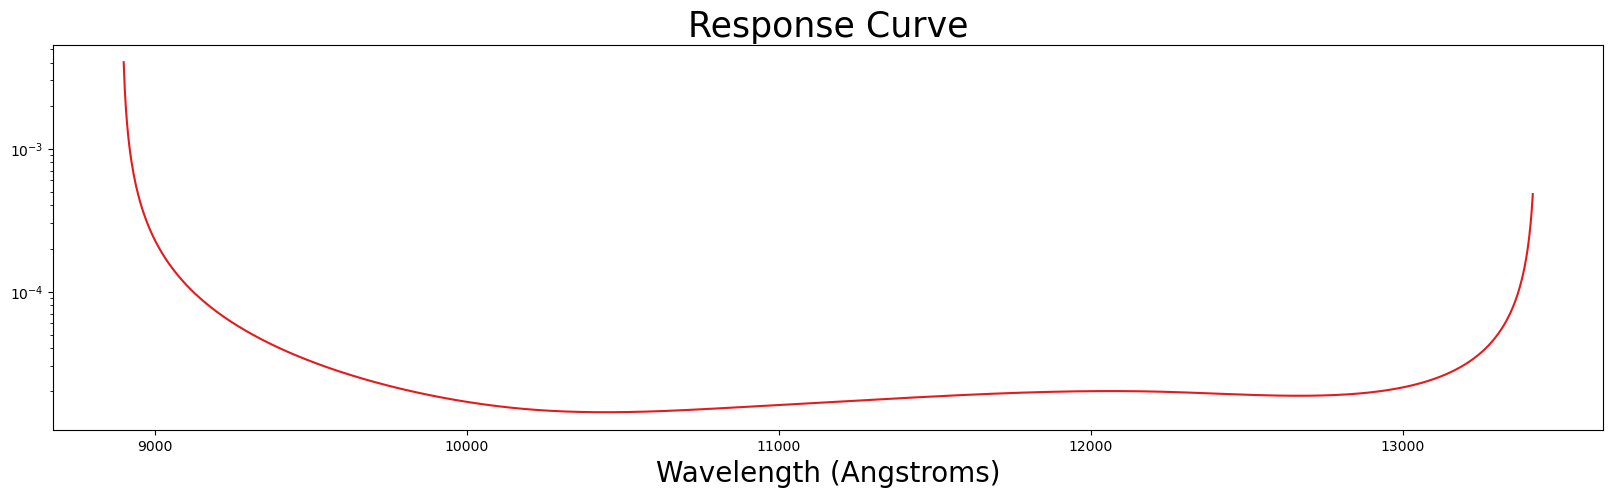

In [7]:
resp_wave, resp = o12.get_response_curve('YJ')

fig, ax = plt.subplots(1,1, figsize=(20,5))
ax.plot(resp_wave, resp)
ax.set_xlabel('Wavelength (Angstroms)', fontsize=20)
ax.set_yscale('log')
ax.set_title("Response Curve", fontsize=25)


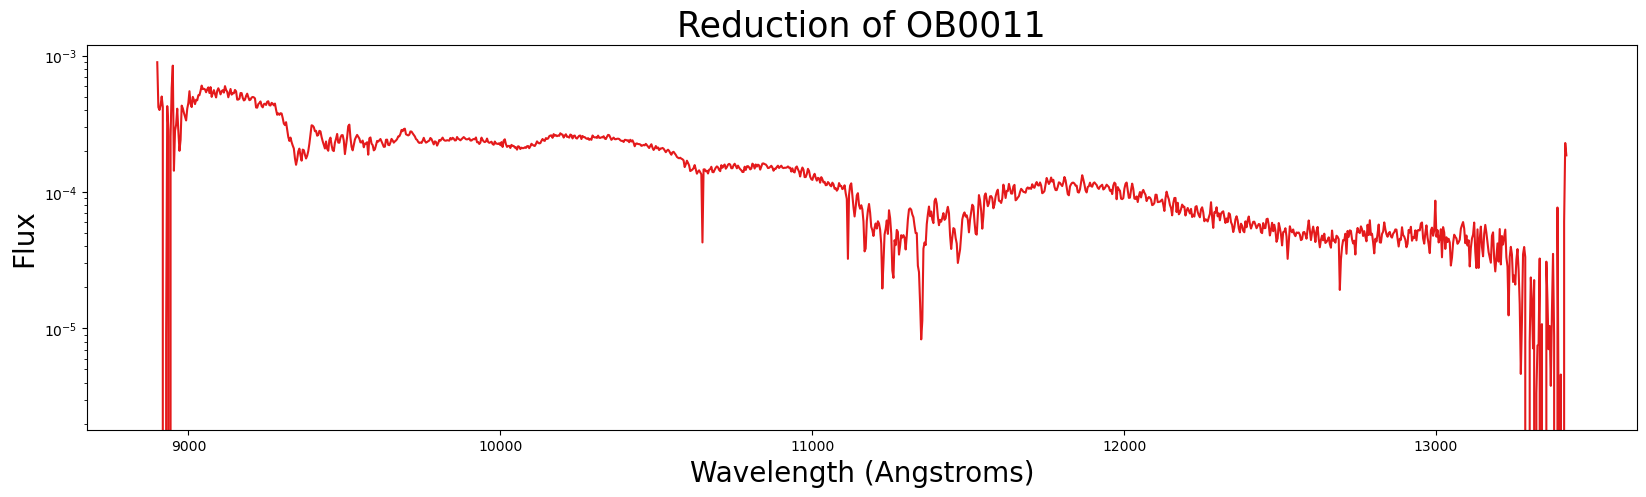

In [8]:
fig, ax = plt.subplots(1,1, figsize=(20,5))
ax.plot(wave, flux)
ax.set_xlabel('Wavelength (Angstroms)', fontsize=20) ; ax.set_ylabel('Flux', fontsize=20)
ax.set_yscale('log')
ax.set_title("Reduction of OB0011", fontsize=25)

plt.show()